In [174]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Funzione gaussiana
def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Apri il file ROOT
file = uproot.open("/home/riccardo-speziali/after_waveforms_analysis/sampic_mcp_setup_run218_final.root")
tree = file["picoTree"]

# Converti in Awkward Array
data = tree.arrays(library="ak")

# Estrai branch rilevanti
Cell0TimeStamp_PICOSEC = data["Cell0timeSTamp_PICOSEC"]  # array di array
Cell0TimeStamp_MCP    = data["Cell0timestamp_MCP"]       # array piatto
cfd_PICO              = data["pulses_time_cfd30"]       # array di array
cfd_MCP               = data["mcp_time_cfd30"]          # array piatto
hits                  = data["hit_x_event"]             # numero di hit per evento
channel               = data["chanel_PICOSEC"]         # canale PICOSEC
srs                   = data["TriggerIDSRS_MCP"]      # Trigger ID SRS
amplitude_PICOSEC     = data["pulses_amplitude"]     # array di array
e_peak_PICOSEC        = data["pulses_integral"]        # array di array
track_chi_2          = data["track_chi_2"]             # chi2 del track




num_channel = 83

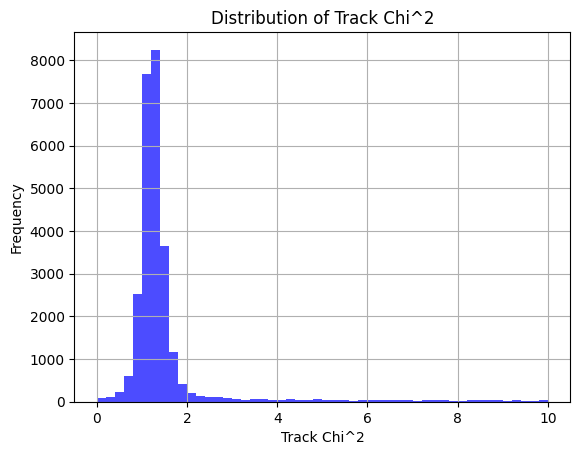

In [175]:
#fit track chi_2
chi_2_values = ak.to_numpy(track_chi_2)
chi_2_values = chi_2_values[~np.isnan(chi_2_values)]
plt.hist(chi_2_values, bins=50, range=(0, 10), alpha=0.7, color='blue')
plt.xlabel('Track Chi^2')
plt.ylabel('Frequency')
plt.title('Distribution of Track Chi^2')
plt.grid()
plt.show()

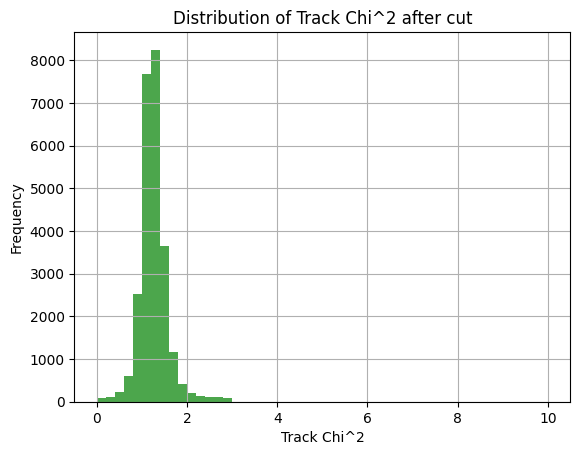

In [176]:
#keep events with good track fit anche per eventi con più di un hit
good_track_mask = chi_2_values < 3
good_tracks = ak.mask(track_chi_2, good_track_mask)
#plot track chi_2 distribution after cut
good_chi_2_values = ak.to_numpy(good_tracks)
good_chi_2_values = good_chi_2_values[~np.isnan(good_chi_2_values)]
plt.hist(good_chi_2_values, bins=50, range=(0, 10), alpha=0.7, color='green')
plt.xlabel('Track Chi^2')
plt.ylabel('Frequency')
plt.title('Distribution of Track Chi^2 after cut')
plt.grid()
plt.show()



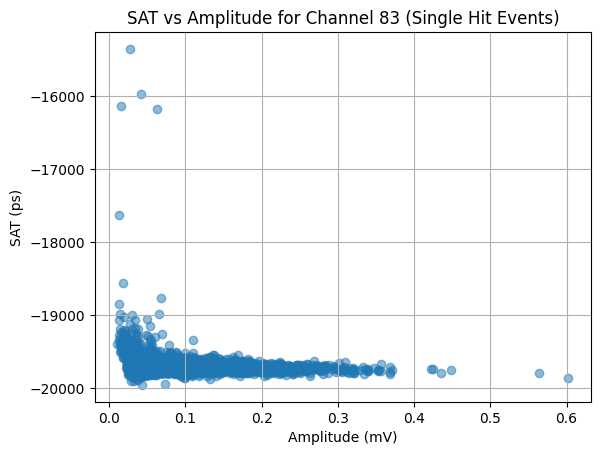

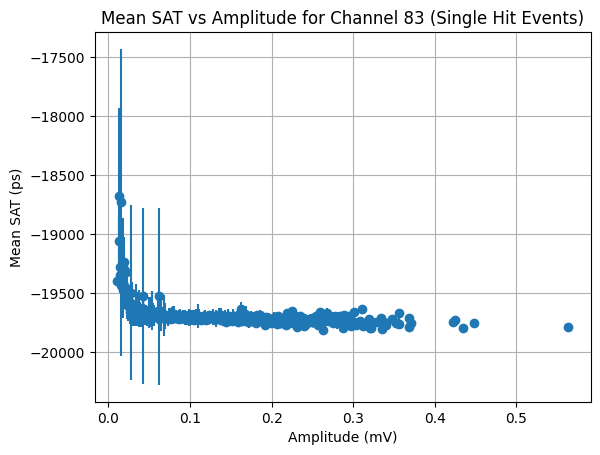

In [177]:
channel_mask = channel[:, 0] == num_channel
single_hit_mask = hits == 1

valid_mask = (
    (ak.num(amplitude_PICOSEC) >= 1) &
    (ak.num(cfd_PICO) >= 1) &
    good_track_mask
)

event_mask = channel_mask & single_hit_mask & valid_mask

good_amplitude = amplitude_PICOSEC[event_mask][:,0]





good_SAT = cfd_PICO[event_mask][:,0] - cfd_MCP[event_mask] - (Cell0TimeStamp_MCP[event_mask]*1e3-Cell0TimeStamp_PICOSEC[event_mask][:,0]*1e3)





plt.scatter(good_amplitude, good_SAT, alpha=0.5)
plt.xlabel('Amplitude (mV)')
plt.ylabel('SAT (ps)')
plt.title(f'SAT vs Amplitude for Channel {num_channel} (Single Hit Events)')
plt.grid()
plt.show()



#altro plot dividere il grafico in bin e prendere la media per ogni bin
bins = np.linspace(ak.min(good_amplitude), ak.max(good_amplitude), 1000)
bin_indices = np.digitize(good_amplitude, bins)

bin_means = []
bin_std = []
bin_echarge_means = []
bin_echarge_std = []
for i in range(1, len(bins)):
    mask = bin_indices == i
    if ak.sum(mask) > 0:
        bin_means.append(ak.mean(good_SAT[mask]))
        bin_std.append(ak.std(good_SAT[mask]))
        bin_echarge_means.append(ak.mean(e_peak_PICOSEC[event_mask][:,0][mask]))
        bin_echarge_std.append(ak.std(e_peak_PICOSEC[event_mask][:,0][mask]))
    else:
        bin_means.append(np.nan)
        bin_std.append(np.nan)
        bin_echarge_means.append(np.nan)
        bin_echarge_std.append(np.nan)

bin_centers = 0.5 * (bins[:-1] + bins[1:])

plt.errorbar(bin_centers, bin_means, bin_std, marker='o')
plt.xlabel('Amplitude (mV)')
plt.ylabel('Mean SAT (ps)')
plt.title(f'Mean SAT vs Amplitude for Channel {num_channel} (Single Hit Events)')
plt.grid()
plt.show()



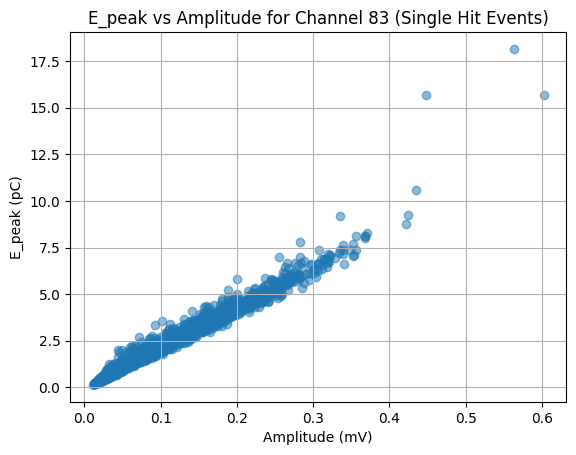

In [178]:
#amplitude vs e_peak
epeak_mask = ak.num(e_peak_PICOSEC) >= 1
valid_epeak_mask = event_mask & epeak_mask
good_epeak = e_peak_PICOSEC[valid_epeak_mask][:,0]

plt.scatter(good_amplitude, good_epeak, alpha=0.5)
plt.xlabel('Amplitude (mV)')
plt.ylabel('E_peak (pC)')
plt.title(f'E_peak vs Amplitude for Channel {num_channel} (Single Hit Events)')
plt.grid()
plt.show()



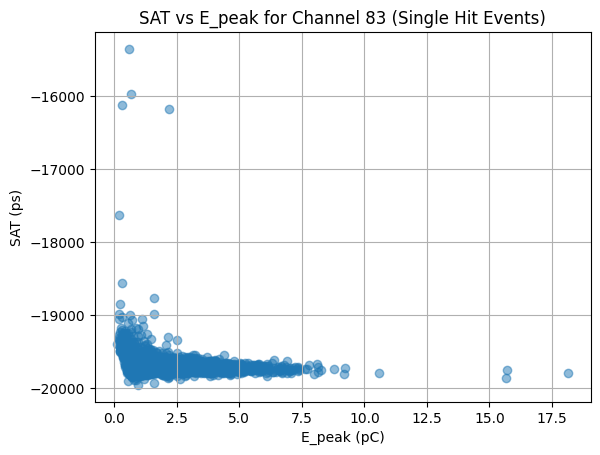

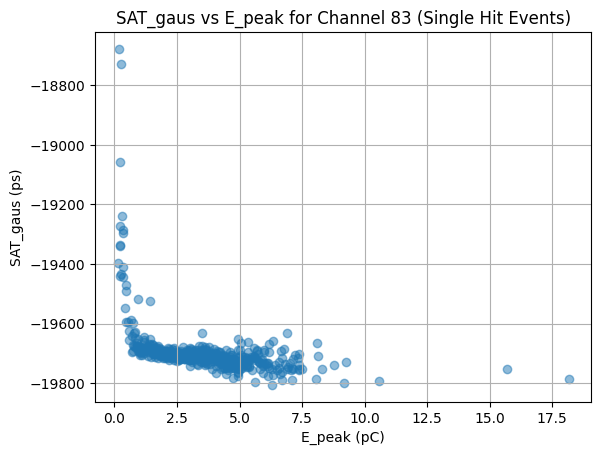

In [179]:
#sat vs charge
plt.scatter( good_epeak, good_SAT, alpha=0.5)
plt.xlabel('E_peak (pC)')
plt.ylabel('SAT (ps)')
plt.title(f'SAT vs E_peak for Channel {num_channel} (Single Hit Events)')
plt.grid()  
plt.show()


#sat_gaus vs charge


plt.scatter(bin_echarge_means, bin_means, alpha=0.5)
plt.xlabel('E_peak (pC)')
plt.ylabel('SAT_gaus (ps)')
plt.title(f'SAT_gaus vs E_peak for Channel {num_channel} (Single Hit Events)')
plt.grid()
plt.show()


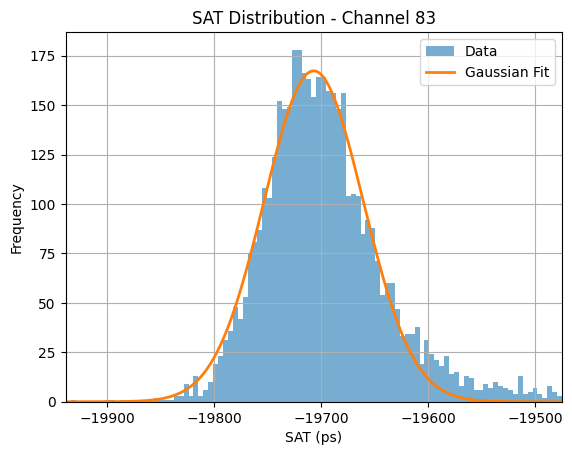

mu = -19707.09 ps, sigma = 46.37 ps


In [180]:
# pulizia dati
sat_values = ak.to_numpy(good_SAT)
sat_values = sat_values[~np.isnan(sat_values)]

mean = np.mean(sat_values)
std = np.std(sat_values)
#sat_values = sat_values[(sat_values > mean - 5*std) & (sat_values < mean + 5*std)]

# bin più ragionevoli
bins = 1000

# istogramma
hist, bin_edges = np.histogram(sat_values, bins=bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# fit gaussiano
popt, pcov = curve_fit(
    gauss,
    bin_centers,
    hist,
    p0=[max(hist), mean, std]
)

A_fit, mu_fit, sigma_fit = popt

# curva fit
x_fit = np.linspace(bin_edges[0], bin_edges[-1], 2000)
y_fit = gauss(x_fit, *popt)

# plot
plt.hist(sat_values, bins=bins, alpha=0.6, label='Data')
plt.plot(x_fit, y_fit, linewidth=2, label='Gaussian Fit')

plt.xlabel('SAT (ps)')
plt.ylabel('Frequency')
plt.title(f'SAT Distribution - Channel {num_channel}')
plt.xlim(mu_fit - 5*sigma_fit, mu_fit + 5*sigma_fit)
plt.legend()
plt.grid()
plt.show()

print(f"mu = {mu_fit:.2f} ps, sigma = {sigma_fit:.2f} ps")

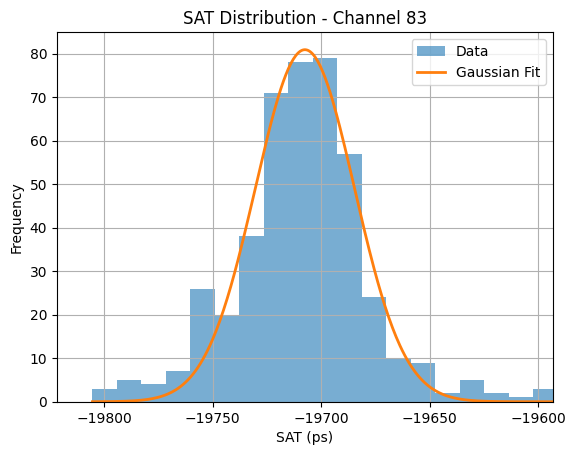

mu = -19707.43 ps, sigma = 22.85 ps


In [181]:
# pulizia dati
sat_values = ak.to_numpy(bin_means)
sat_values = sat_values[~np.isnan(sat_values)]

mean = np.mean(sat_values)
std = np.std(sat_values)
#sat_values = sat_values[(sat_values > mean - 5*std) & (sat_values < mean + 5*std)]

# bin più ragionevoli
bins = 100

# istogramma
hist, bin_edges = np.histogram(sat_values, bins=bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# fit gaussiano
popt, pcov = curve_fit(
    gauss,
    bin_centers,
    hist,
    p0=[max(hist), mean, std]
)

A_fit, mu_fit, sigma_fit = popt

# curva fit
x_fit = np.linspace(bin_edges[0], bin_edges[-1], 2000)
y_fit = gauss(x_fit, *popt)

# plot
plt.hist(sat_values, bins=bins, alpha=0.6, label='Data')
plt.plot(x_fit, y_fit, linewidth=2, label='Gaussian Fit')

plt.xlabel('SAT (ps)')
plt.ylabel('Frequency')
plt.title(f'SAT Distribution - Channel {num_channel}')
plt.xlim(mu_fit - 5*sigma_fit, mu_fit + 5*sigma_fit)
plt.legend()
plt.grid()
plt.show()

print(f"mu = {mu_fit:.2f} ps, sigma = {sigma_fit:.2f} ps")

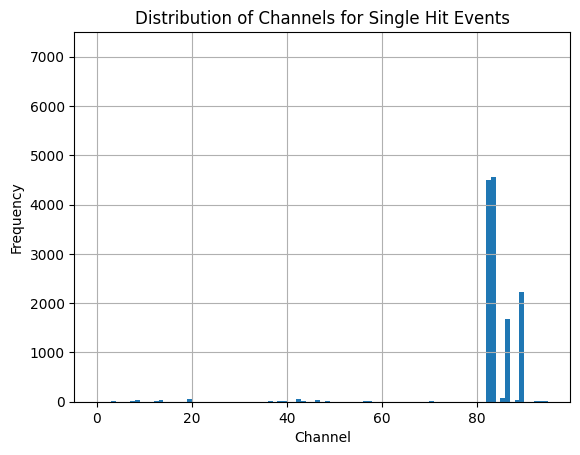

In [182]:
#most hitted channels
mask_here = single_hit_mask & valid_mask & good_track_mask
plt.hist(channel[mask_here][:, 0], bins=np.arange(0, 96, 1), alpha=1)
plt.xlabel('Channel')
plt.ylabel('Frequency')
plt.title('Distribution of Channels for Single Hit Events')
plt.ylim(0, 7500)  # Imposta un limite massimo per l'asse y
plt.grid()
plt.show()

In [183]:
flat_channels = channel[mask_here][:, 0]
flat_channels

<Array [83, 89, 89, 89, 82, 89, ..., 83, 82, 82, 82, 89] type='13573 * int32'>

In [184]:
# funziona che mi ordina i canali piu colpiti indicandomi anche il numero di eventi con 1 hit

#flat_channels = ak.flatten(channel[single_hit_mask])
#channel_counts = np.bincount(flat_channels)
channel_counts = np.bincount(flat_channels)
sorted_indices = np.argsort(channel_counts)[::-1]
sorted_channels = np.arange(96)[sorted_indices]
sorted_counts = channel_counts[sorted_indices]

print("Canali più colpiti (ordinati):")
for ch, count in zip(sorted_channels, sorted_counts):
    print(f"Canale {ch}: {count} eventi")

Canali più colpiti (ordinati):
Canale 83: 4562 eventi
Canale 82: 4507 eventi
Canale 89: 2227 eventi
Canale 86: 1675 eventi
Canale 85: 85 eventi
Canale 19: 62 eventi
Canale 42: 53 eventi
Canale 13: 41 eventi
Canale 46: 31 eventi
Canale 8: 30 eventi
Canale 88: 29 eventi
Canale 93: 14 eventi
Canale 48: 13 eventi
Canale 92: 11 eventi
Canale 7: 11 eventi
Canale 3: 11 eventi
Canale 43: 9 eventi
Canale 12: 8 eventi
Canale 36: 8 eventi
Canale 70: 8 eventi
Canale 56: 8 eventi
Canale 95: 8 eventi
Canale 38: 7 eventi
Canale 57: 5 eventi
Canale 39: 5 eventi
Canale 51: 4 eventi
Canale 50: 4 eventi
Canale 55: 4 eventi
Canale 79: 4 eventi
Canale 37: 4 eventi
Canale 25: 4 eventi
Canale 75: 4 eventi
Canale 5: 4 eventi
Canale 72: 4 eventi
Canale 52: 4 eventi
Canale 21: 3 eventi
Canale 20: 3 eventi
Canale 11: 3 eventi
Canale 91: 3 eventi
Canale 40: 3 eventi
Canale 41: 3 eventi
Canale 94: 3 eventi
Canale 77: 3 eventi
Canale 49: 3 eventi
Canale 0: 3 eventi
Canale 53: 3 eventi
Canale 73: 3 eventi
Canale 76: